In [1]:
# 安装所需软件包

!pip install -U langgraph langsmith

  Using cached langgraph-1.0.6-py3-none-any.whl.metadata (7.4 kB)
  Using cached langsmith-0.6.4-py3-none-any.whl.metadata (15 kB)
  Using cached langchain_core-1.2.7-py3-none-any.whl.metadata (3.7 kB)
Using cached langgraph-1.0.6-py3-none-any.whl (157 kB)
Using cached langsmith-0.6.4-py3-none-any.whl (283 kB)
Using cached langchain_core-1.2.7-py3-none-any.whl (490 kB)
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.1.147
    Uninstalling langsmith-0.1.147:
      Successfully uninstalled langsmith-0.1.147
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.0
    Uninstalling langchain-core-0.3.0:0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [langchain-core]
      Successfully uninstalled langchain-core-0.3.0━━━━━━━━━━━ 1/3 [langchain-core]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [langgraph]/3 [langgraph]core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This be

In [3]:
import os
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())  # 👈 必须加这行来读取 .env 文件

In [4]:
# langgraph Hello World
from langgraph.prebuilt import create_react_agent
from langchain_community.chat_models import ChatTongyi

llm = ChatTongyi(
    model_name="qwen-turbo",
    temperature=0.7,
    streaming=True
)

agent = create_react_agent(
    model = llm,
    tools = [],
    prompt= "You are a helpful assistant."
)

# agent.invoke({"message":[{"role":"user","content":"Hello, how can I help you?"}]})
for chunk in agent.stream(
    {"message":[{"role":"user","content":"你是谁？"}]},
    stream_mode = "messages"
):
    print(chunk)
    print("\n")



/var/folders/77/wn2nxhbs4rx6vwtr4mkcww780000gn/T/ipykernel_45133/3451535095.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


(AIMessageChunk(content='Hello', additional_kwargs={}, response_metadata={}, id='lc_run--019bc91e-3940-7443-8713-6430069f3f6f', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:6a0330a0-d34e-a3d1-b6e1-32a248c9f553', 'checkpoint_ns': 'agent:6a0330a0-d34e-a3d1-b6e1-32a248c9f553', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_name': 'qwen-turbo'})


(AIMessageChunk(content='!', additional_kwargs={}, response_metadata={}, id='lc_run--019bc91e-3940-7443-8713-6430069f3f6f', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:6a0330a0-d34e-a3d1-b6e1-32a248c9f553', 'checkpoint_ns': 'agent:6a0330a0-d34e-a3d1-b6e1-32a248c9f

创建一个 StateGraph 为“状态机”,添加 节点 来表示 LLM 和聊天机器人可以调用的函数，并添加 边 来指定机器人应如何在这些函数之间进行转换。

> 定义：定义图时，第一步是定义其 状态。状态 包括图的模式和处理状态更新的 reducer 函数。在我们的示例中，状态 是一个具有一个键：messages 的 TypedDict。 add_messages reducer 函数用于将新消息追加到列表中，而不是覆盖它。没有 reducer 注解的键将覆盖先前的值。

In [5]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

我们的图现在可以处理两个关键任务

每个 节点 都可以接收当前 状态 作为输入，并输出状态的更新。
对 消息 的更新将追加到现有列表而不是覆盖它。


接下来，添加一个“chatbot”节点。 节点 表示工作单元，通常是普通的 Python 函数。

```python
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = "sk-..."

llm = init_chat_model("openai:gpt-4.1")
```

In [6]:
from langchain_community.chat_models import ChatTongyi
# 或者使用
# from langchain_community.llms import Tongyi

# 设置通义千问的 API Key
# os.environ["DASHSCOPE_API_KEY"] = "your-dashscope-api-key"

# 初始化通义千问模型
llm = ChatTongyi(
    model_name="qwen-turbo",  # 或者 "qwen-plus", "qwen-max"
    temperature=0.7,
    streaming=True
)

将聊天模型集成到一个简单的节点中

In [7]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

添加一个 入口 点，以告诉图每次运行时**从何处开始工作**

In [8]:
graph_builder.add_edge(START, "chatbot")

在运行图之前，我们需要对其进行编译。我们可以通过在图构建器上调用 compile() 来完成。这将创建一个 CompiledGraph，我们可以在我们的状态上调用它。

In [9]:
graph = graph_builder.compile()

您可以使用 get_graph 方法和其中一个“绘图”方法（例如 draw_ascii 或 draw_png）来可视化图。这些 draw 方法都需要额外的依赖项。

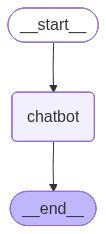

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

运行聊天机器人,通过键入 quit、exit 或 q 来退出聊天循环。

In [11]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: LangGraph is a powerful framework for building complex, multi-step applications using language models (LLMs). It allows developers to create workflows that can handle tasks such as data processing, decision-making, and interaction with external systems. Here's an overview of what I know about LangGraph:

### 1. **Core Concepts**
- **Nodes**: These are the individual steps or functions in the workflow. Each node can perform a specific task, such as calling an API, processing text, or making a decision.
- **Edges**: These define the flow between nodes, specifying how the output of one node is passed to another.
- **State**: A shared context that is passed through the graph, allowing nodes to access and modify data as needed.

### 2. **Key Features**
- **Modular Design**: LangGraph allows you to break down complex tasks into smaller, manageable components, making it easier to develop, test, and maintain applications.
- **Dynamic Workflows**: The framework supports dynamic routi